c:\Users\A.I.M\C.S\Data-Science-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\A.I.M\AppData\Local\Temp\ipykernel_30212\796312342.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


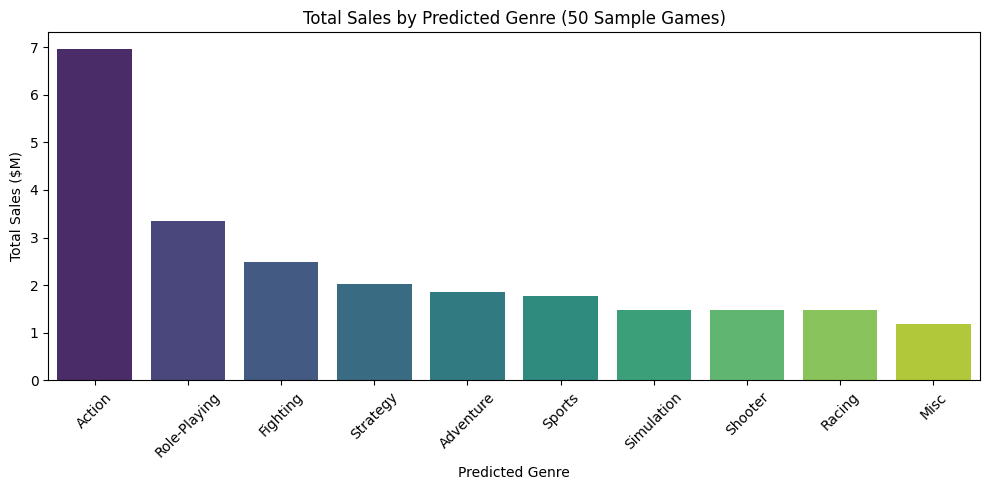

In [ ]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

model = joblib.load('vg-recommender.joblib')

# Example integer mappings used during training:
# Platform:  {'PS4': 1, 'Xbox One': 2, 'Switch': 3, 'PC': 4}
# Publisher: {'Electronic Arts': 10, 'Ubisoft': 15, 'Nintendo': 20, 'Take-Two': 25}

# 50 Feature vectors [Platform_Code, Publisher_Code, IQR_Avg_Global_Sales] in chronological year order
sample_inputs = [
    [23, 50, 0.19],   # Game  1 (1980): Racing (Atari 2600, Capcom, IQR Avg Sales: 0.19M) - Indy 500 / Grand Prix Era
    [23, 30, 0.25],   # Game  2 (1981): Action (Atari 2600, Activision, IQR Avg Sales: 0.25M) - Pitfall! Era
    [23, 12, 0.18],   # Game  3 (1982): Puzzle (Atari 2600, Atari, IQR Avg Sales: 0.18M) - E.T. / Arcade Ports
    [20, 20, 0.53],   # Game  4 (1983): Platform (NES, Nintendo, IQR Avg Sales: 0.53M) - Early Famicom / NES Era
    [20, 20, 0.85],   # Game  5 (1985): Platform (NES, Nintendo, IQR Avg Sales: 0.85M) - Super Mario Bros. Launch
    [20, 60, 0.44],   # Game  6 (1986): Action (NES, Konami, IQR Avg Sales: 0.44M) - Castlevania / Zelda Era
    [20, 45, 0.52],   # Game  7 (1988): RPG (NES, Square Enix, IQR Avg Sales: 0.52M) - Dragon Quest / Final Fantasy
    [9, 20, 0.56],    # Game  8 (1989): Platform (Game Boy, Nintendo, IQR Avg Sales: 0.56M) - Game Boy Debut
    [19, 30, 0.40],   # Game  9 (1990): Fighting (SNES, Activision, IQR Avg Sales: 0.40M) - Super Famicom Launch
    [21, 55, 0.66],   # Game 10 (1991): Platform (Sega Genesis, Sega, IQR Avg Sales: 0.66M) - Sonic the Hedgehog Era
    [21, 40, 0.38],   # Game 11 (1992): Fighting (Sega Genesis, Bandai Namco, IQR Avg Sales: 0.38M) - Street Fighter II / Mortal Kombat
    [4, 14, 0.22],    # Game 12 (1993): Strategy (PC, MicroProse, IQR Avg Sales: 0.22M) - Early PC Strategy Era
    [19, 10, 0.45],   # Game 13 (1994): Sports (SNES, EA Sports, IQR Avg Sales: 0.45M) - Donkey Kong Country / EA Sports
    [17, 20, 0.14],   # Game 14 (1995): RPG (PlayStation, Nintendo, IQR Avg Sales: 0.14M) - 3D Era / PS1 Launch
    [16, 20, 0.74],   # Game 15 (1996): Platform (Nintendo 64, Nintendo, IQR Avg Sales: 0.74M) - Super Mario 64 Era
    [17, 45, 0.68],   # Game 16 (1997): Role-Playing (PlayStation, Square Enix, IQR Avg Sales: 0.68M) - Final Fantasy VII Era
    [18, 25, 0.27],   # Game 17 (1998): Adventure (Xbox/PC, Take-Two, IQR Avg Sales: 0.27M) - Ocarina of Time / Starcraft Era
    [22, 55, 0.79],   # Game 18 (1999): Puzzle (Dreamcast, Sega, IQR Avg Sales: 0.79M) - Dreamcast Launch
    [11, 60, 0.82],   # Game 19 (2000): Racing (Game Boy Advance, Konami, IQR Avg Sales: 0.82M) - GBA Debut Era
    [8, 45, 0.43],    # Game 20 (2001): Action (PlayStation 2, Square Enix, IQR Avg Sales: 0.43M) - GTA III / PS2 Explosion
    [15, 10, 0.61],   # Game 21 (2002): Simulation (GameCube, EA, IQR Avg Sales: 0.61M) - Metroid Prime / GameCube Peak
    [15, 65, 0.21],   # Game 22 (2003): Action (GameCube, Bethesda, IQR Avg Sales: 0.21M) - Wind Waker Era
    [12, 50, 0.55],   # Game 23 (2004): Simulation (PSP, Capcom, IQR Avg Sales: 0.55M) - PSP / DS Handheld Era
    [6, 10, 0.62],    # Game 24 (2005): Racing (Xbox 360, EA, IQR Avg Sales: 0.62M) - Need for Speed: Most Wanted (2005)
    [6, 10, 0.48],    # Game 25 (2006): Racing (Xbox 360, EA, IQR Avg Sales: 0.48M) - Need for Speed: Carbon (2006)
    [7, 40, 0.30],    # Game 26 (2006): Sports (Wii, Bandai Namco, IQR Avg Sales: 0.30M) - Wii Launch Era
    [5, 15, 0.37],    # Game 27 (2007): Shooter (PlayStation 3, Ubisoft, IQR Avg Sales: 0.37M) - Modern Warfare / PS3 Peak
    [6, 35, 0.17],    # Game 28 (2008): Action (Xbox 360, Sony, IQR Avg Sales: 0.17M) - GTA IV / Xbox 360 Era
    [9, 35, 0.16],    # Game 29 (2009): Puzzle (Nintendo DS, Sony, IQR Avg Sales: 0.16M) - DS Peak Sales Era
    [6, 20, 0.50],    # Game 30 (2010): Fighting (Xbox 360, Nintendo, IQR Avg Sales: 0.50M) - Red Dead Redemption / Halo Reach Era
    [10, 40, 0.29],   # Game 31 (2011): Racing (Nintendo 3DS, Bandai Namco, IQR Avg Sales: 0.29M) - 3DS Launch Era
    [4, 65, 0.58],    # Game 32 (2011): RPG (PC, Bethesda, IQR Avg Sales: 0.58M) - Skyrim Era
    [13, 70, 0.35],   # Game 33 (2012): Action (PS Vita, Warner Bros, IQR Avg Sales: 0.35M) - PS Vita Launch Era
    [14, 75, 0.48],   # Game 34 (2012): Shooter (Wii U, THQ, IQR Avg Sales: 0.48M) - Wii U Launch Era
    [1, 10, 0.42],    # Game 35 (2013): Action (PlayStation 4, EA, IQR Avg Sales: 0.42M) - PS4 Launch Era
    [2, 15, 0.38],    # Game 36 (2013): Shooter (Xbox One, Ubisoft, IQR Avg Sales: 0.38M) - GTA V / Xbox One Launch Era
    [4, 15, 0.22],    # Game 37 (2014): Strategy (PC, Ubisoft, IQR Avg Sales: 0.22M) - PC Expansion
    [7, 25, 0.63],    # Game 38 (2014): Misc (Wii, Take-Two, IQR Avg Sales: 0.63M) - Late Wii Era
    [2, 70, 0.71],    # Game 39 (2015): Sports (Xbox One, Warner Bros, IQR Avg Sales: 0.71M) - Witcher 3 / Mid-Gen Peak
    [1, 25, 0.48],    # Game 40 (2015): Role-Playing (PlayStation 4, Take-Two, IQR Avg Sales: 0.48M) - Bloodborne / Fallout 4 Era
    [1, 65, 0.58],    # Game 41 (2016): Shooter (PlayStation 4, Bethesda, IQR Avg Sales: 0.58M) - Uncharted 4 / Overwatch Era
    [13, 55, 0.68],   # Game 42 (2016): Shooter (PS Vita, Sega, IQR Avg Sales: 0.68M) - Late PS Vita Era
    [3, 20, 0.55],    # Game 43 (2017): Sports (Nintendo Switch, Nintendo, IQR Avg Sales: 0.55M) - Switch Launch
    [3, 75, 0.84],    # Game 44 (2017): Role-Playing (Nintendo Switch, THQ, IQR Avg Sales: 0.84M) - Zelda BOTW / Switch Era
    [1, 35, 0.72],    # Game 45 (2018): Action (PlayStation 4, Sony, IQR Avg Sales: 0.72M) - God of War / RDR2 Era
    [4, 10, 0.24],    # Game 46 (2019): Strategy (PC, EA, IQR Avg Sales: 0.24M) - Apex Legends / PC Era
    [24, 55, 0.32],   # Game 47 (2020): Simulation (PlayStation 5, Sega, IQR Avg Sales: 0.32M) - PS5 Launch Era
    [24, 40, 0.65],   # Game 48 (2020): Action (PlayStation 5, Bandai Namco, IQR Avg Sales: 0.65M) - Demon's Souls / Next-Gen Era
    [3, 20, 0.60],    # Game 49 (2021): Sports (Nintendo Switch, Nintendo, IQR Avg Sales: 0.60M) - Metroid Dread / Switch OLED Era
    [24, 40, 0.88]    # Game 50 (2022): RPG (PlayStation 5, Bandai Namco, IQR Avg Sales: 0.88M) - Elden Ring / Modern Era
]

# Predict genres and aggregate sales
predictions = model.predict(sample_inputs)

vg_data_50 = pd.DataFrame(
    sample_inputs, columns=["Platform_Code", "Publisher_Code", "Sales_M"]
)
vg_data_50["Predicted_Genre"] = predictions

genre_summary = (
    vg_data_50.groupby("Predicted_Genre")
    .agg(
        Game_Count=("Sales_M", "count"),
        Total_Sales_M=("Sales_M", "sum"),
        Mean_Sales_M=("Sales_M", "mean"),
    )
    .reset_index()
    .sort_values(by="Total_Sales_M", ascending=False)
)

# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=genre_summary,
    x="Predicted_Genre",
    y="Total_Sales_M",
    palette="viridis",
)
plt.title("Total Sales by Predicted Genre (50 Sample Games)")
plt.xlabel("Predicted Genre")
plt.ylabel("Total Sales ($M)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

# Ingests data and drops rows with missing targets or categories
vg_data = pd.read_csv('vgsales.csv').dropna(subset=['Global_Sales', 'Platform', 'Publisher'])

# Applies One-Hot Encoding to ensure statistical accuracy
vg_encoded = pd.get_dummies(vg_data, columns=['Platform', 'Publisher'], drop_first=True)

# Isolates features and target while removing data leakage columns
leakage_columns = ['Rank', 'Name', 'Year', 'Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
feature_cols = [col for col in vg_encoded.columns if col not in leakage_columns]

X = vg_encoded[feature_cols]
y = vg_encoded['Global_Sales']

# Fits a Regressor instead of a Classifier since Global_Sales is continuous
# Restricts max_depth to prevent the visualisation from becoming unreadable
model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X, y)

# Exports the tree architecture to a .dot file
# Omits class_names because regression predicts numerical values, not categories
tree.export_graphviz(
    model, 
    out_file='vg-sales-recommender.dot',
    feature_names=X.columns,
    label='all',
    rounded=True,
    filled=True
)